# 05 — LSTM

## 1. Définition du problème

Il s'agit d'une classification séquentielle **many-to-one** : une fenêtre physiologique produit un seul logit binaire stress/non-stress, et non une séquence de sorties.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from src.config import *
from src.evaluation import binary_metrics, collect_probabilities, per_subject_metrics, prediction_table, select_threshold
from src.helpers import count_parameters, set_seed
from src.training import pos_weight_from_labels, save_model_artifacts, train_with_early_stopping

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Périphérique :", device, "| CUDA :", torch.cuda.is_available())

Périphérique : cuda | CUDA : True


## 2. Formes d'entrée et de sortie

L'entrée réelle a la forme `(batch_size, 960, 6)` et la sortie `(batch_size, 1)`. Toutes les fenêtres ont exactement 960 pas ; aucun padding ni masque artificiel n'est nécessaire.

In [2]:
sequence_dir = PROJECT_ROOT / "data" / "processed" / "sequence"
metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
X_train = torch.load(sequence_dir / "X_train.pt", map_location="cpu", weights_only=True).float()
y_train = torch.load(sequence_dir / "y_train.pt", map_location="cpu", weights_only=True).float()
X_validation = torch.load(sequence_dir / "X_validation.pt", map_location="cpu", weights_only=True).float()
y_validation = torch.load(sequence_dir / "y_validation.pt", map_location="cpu", weights_only=True).float()
X_test = torch.load(sequence_dir / "X_test.pt", map_location="cpu", weights_only=True).float()
y_test = torch.load(sequence_dir / "y_test.pt", map_location="cpu", weights_only=True).float()
metadata_train = pd.read_csv(metadata_dir / "windows_train.csv")
metadata_validation = pd.read_csv(metadata_dir / "windows_validation.csv")
metadata_test = pd.read_csv(metadata_dir / "windows_test.csv")

train_subjects = set(metadata_train.subject_id)
val_subjects = set(metadata_validation.subject_id)
test_subjects = set(metadata_test.subject_id)
assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)
assert X_train.shape[1:] == X_validation.shape[1:] == X_test.shape[1:] == (960, 6)
assert torch.isfinite(X_train).all() and torch.isfinite(X_validation).all() and torch.isfinite(X_test).all()
print("Train/validation/test :", X_train.shape, X_validation.shape, X_test.shape)

Train/validation/test : torch.Size([1429, 960, 6]) torch.Size([287, 960, 6]) torch.Size([426, 960, 6])


## 3. Équations du LSTM


\[
\begin{aligned}
f_t&=\sigma(W_f[x_t,h_{t-1}]+b_f),\\
i_t&=\sigma(W_i[x_t,h_{t-1}]+b_i),\\
\tilde c_t&=\tanh(W_c[x_t,h_{t-1}]+b_c),\\
c_t&=f_t\odot c_{t-1}+i_t\odot\tilde c_t,\\
o_t&=\sigma(W_o[x_t,h_{t-1}]+b_o),\quad h_t=o_t\odot\tanh(c_t).
\end{aligned}
\]

La porte d'oubli contrôle la mémoire conservée, la porte d'entrée contrôle l'écriture de la mémoire candidate, et la porte de sortie contrôle l'état caché exposé. Le chemin additif de la cellule peut faciliter la circulation d'information à long terme. Ces quatre transformations expliquent le nombre de paramètres supérieur à celui d'un RNN simple.

## 4. Architecture du modèle

In [3]:
from src.models import LSTMClassifier
HIDDEN_SIZE = 32
model = LSTMClassifier(input_size=6, hidden_size=HIDDEN_SIZE).to(device)
print(model)
print('Paramètres :', count_parameters(model))

LSTMClassifier(
  (lstm): LSTM(6, 32, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Paramètres : 6209


## 5. Petit exemple synthétique

In [4]:
batch_size, sequence_length, input_size = 2, 5, 6
x = torch.randn(batch_size, sequence_length, input_size, device=device)
print(x.shape)

torch.Size([2, 5, 6])


## 6. Forward pass et états récurrents

In [5]:
outputs, (hidden, cell) = model.lstm(x)
print("Input:", x.shape)
print("All recurrent outputs:", outputs.shape)
print("Hidden state:", hidden.shape)
print("Cell state:", cell.shape)
print("Last layer hidden state:", hidden[-1].shape)

Input: torch.Size([2, 5, 6])
All recurrent outputs: torch.Size([2, 5, 32])
Hidden state: torch.Size([1, 2, 32])
Cell state: torch.Size([1, 2, 32])
Last layer hidden state: torch.Size([2, 32])


## 7–9. Interprétation de `outputs`, des états finaux et de `hidden[-1]`

`outputs` contient l'état caché à chaque pas. `hidden` contient le dernier état caché de chaque couche. `cell` contient la mémoire finale de chaque couche : elle peut conserver une information différente de l'état caché exposé. `hidden[-1]` résume la séquence pour le classifieur.

## 10. Logit de classification binaire

In [6]:
logits = model(x)
print('Logits :', logits.shape, logits.detach().cpu())
assert logits.shape == (batch_size, 1)

Logits : torch.Size([2, 1]) tensor([[-0.2327],
        [-0.3133]])


## 11. Calcul de la perte

In [7]:
targets = torch.tensor([0., 1.], device=device)
criterion = nn.BCEWithLogitsLoss()
loss = criterion(logits.reshape(-1), targets)
print('BCEWithLogitsLoss :', float(loss))

BCEWithLogitsLoss : 0.7227912545204163


C:\Users\User\AppData\Local\Temp\ipykernel_15464\1854835874.py:4: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('BCEWithLogitsLoss :', float(loss))


## 12. `loss.backward()` et BPTT

In [8]:
model.zero_grad(set_to_none=True)
loss.backward()
print('Norme du gradient récurrent :', float(getattr(model, 'lstm').weight_hh_l0.grad.norm()))

Norme du gradient récurrent : 0.02071133814752102


## 13. Mise à jour par l'optimiseur

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
optimizer.step()
optimizer.zero_grad(set_to_none=True)

## 14. Entraînement complet

In [10]:
from src.experiments import run_validation_selected_experiment
RUN_FULL_TRAINING = False
if RUN_FULL_TRAINING:
    datasets = (TensorDataset(X_train, y_train), TensorDataset(X_validation, y_validation), TensorDataset(X_test, y_test))
    result = run_validation_selected_experiment(
        lambda: LSTMClassifier(input_size=6, hidden_size=HIDDEN_SIZE), datasets,
        metadata_validation, metadata_test, PROJECT_ROOT / "artifacts/models/lstm_fair",
        {"model": "LSTMClassifier", "model_class": "LSTMClassifier", "architecture": {"hidden_size": HIDDEN_SIZE, "layers": 1, "bidirectional": False},
          "input_shape": [960, 6], "input_representation": "normalized_raw_sequences", "subject_split": SPLIT_SUBJECTS,
          "normalization_statistics": "artifacts/preprocessing/sequence_scaler.joblib"},
        device, compare_weighted_loss=True,
    )
else:
    print("Non exécuté : activer RUN_FULL_TRAINING pour réentraîner le modèle.")

Non exécuté : activer RUN_FULL_TRAINING pour réentraîner le modèle.


## 15. Évaluation et métriques sauvegardées

In [11]:
artifact_dir = PROJECT_ROOT / "artifacts/models/lstm_fair"
if all((artifact_dir / name).exists() for name in ["validation_metrics.json", "test_metrics.json", "threshold.json"]):
    with (artifact_dir / "validation_metrics.json").open(encoding="utf-8") as f: validation_metrics = json.load(f)
    with (artifact_dir / "test_metrics.json").open(encoding="utf-8") as f: test_metrics = json.load(f)
    with (artifact_dir / "threshold.json").open(encoding="utf-8") as f: selected_threshold = json.load(f)["threshold"]
    display(pd.DataFrame({"validation": validation_metrics, "test": test_metrics}))
    print("Seuil sélectionné sur validation :", selected_threshold)
else:
    print("Artefacts absents : exécuter l'entraînement complet.")

,validation,test
accuracy,0.836237,0.734742
macro_f1,0.797137,0.621518
weighted_f1,0.832823,0.704128
non_stress_precision,0.863208,0.756233
non_stress_recall,0.910448,0.916107
stress_precision,0.76,0.615385
stress_recall,0.662791,0.3125
confusion_matrix,"[[183, 18], [29, 57]]","[[273, 25], [88, 40]]"
roc_auc,0.842994,0.694238
average_precision,0.731875,0.573333


Seuil sélectionné sur validation : 0.54


## 15.1 Rechargement du meilleur `state_dict`

In [12]:
checkpoint = artifact_dir / "best_model.pt"
if checkpoint.exists():
    first = LSTMClassifier(input_size=6, hidden_size=HIDDEN_SIZE).to(device)
    second = LSTMClassifier(input_size=6, hidden_size=HIDDEN_SIZE).to(device)
    state = torch.load(checkpoint, map_location=device, weights_only=True)
    first.load_state_dict(state); second.load_state_dict(state); first.eval(); second.eval()
    batch = X_test[:8].to(device)
    with torch.no_grad():
        logits_first, logits_second = first(batch), second(batch)
    torch.testing.assert_close(logits_first, logits_second)
    print("Logits identiques après rechargement.")

Logits identiques après rechargement.


## 16. Matrice de confusion

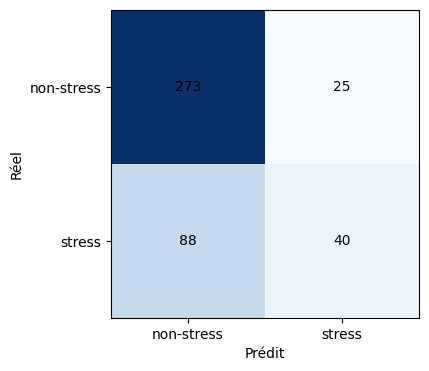

In [13]:
if 'test_metrics' in globals():
    cm = np.asarray(test_metrics['confusion_matrix'])
    fig, ax = plt.subplots(figsize=(4, 4)); ax.imshow(cm, cmap='Blues')
    ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['non-stress','stress'], yticklabels=['non-stress','stress'], xlabel='Prédit', ylabel='Réel')
    for row in range(2):
        for col in range(2): ax.text(col, row, cm[row, col], ha='center', va='center')
    plt.show()

## 17. Interprétation

Le macro-F1 et le rappel stress doivent être examinés avec les résultats par sujet. Une forte validation ne garantit pas la généralisation : seuls quinze participants indépendants sont disponibles et les habitudes physiologiques peuvent varier fortement.

## Ce que je dois retenir pour la soutenance

- La cellule LSTM ajoute une mémoire additive contrôlée par les portes d'oubli, d'entrée et de sortie. Elle possède plus de paramètres, mais ce surcoût ne garantit pas une meilleure généralisation à des sujets inconnus.
- BPTT propage le gradient de la perte vers les états antérieurs.
- Un gradient évanescent devient trop faible pour apprendre des dépendances lointaines ; un gradient explosif devient excessivement grand.
- L'écrêtage limite les gradients explosifs, mais ne restaure pas les gradients évanescents.
- `hidden[-1]` est utilisé parce qu'il correspond à la représentation finale de la dernière couche.
- La performance de validation peut ne pas se transférer aux participants test jamais vus.